# Raw FITS Files

In [1]:
import numpy as np
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
import csv
from scipy.io import readsav
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation
from astropy.io import fits
output_notebook()

NORMALIZATION_INDEX = 800

Loading BokehJS ...

# Headers

In [2]:
image_file = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5035.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file) as hdu_list:
    object_info= hdu_list.info() #display the extensions of the fits file
    primary_header = hdu_list[0].header #store primary header
    extracted_header= hdu_list[1].header #store extracted header
    sky_header= hdu_list[2].header #store sky header
    scan_noise_header= hdu_list[3].header #store noise header

    primary=hdu_list[0]
    
    wavenumber = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber.tolist() #make it into a list

    image_data=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file


Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5035.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


In [3]:
print(primary_header)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 2560                                                  NAXIS2  =                   22                                                  NAXIS3  =                   37                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

In [4]:
print(extracted_header)

XTENSION= 'TABLE   '                                                            BITPIX  =                    8                                                  NAXIS   =                    2                                                  NAXIS1  =                   80                                                  NAXIS2  =                 2560                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  TFIELDS =                    5                                                  EXTNAME = 'EXTRACTED'                                                           TTYPE1  = 'WAVENUMBER'  / observed vacuum wavenumber                            TBCOL1  =                    1                                                  TFORM1  = 'F12.4'                                                               TUNIT1  = 'cm^-1   '                    

In [5]:
print(sky_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 2560                                                  NAXIS2  =                   22                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SKY'  / sky frame which was subtracted from scan frames              BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

In [6]:
print(scan_noise_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 2560                                                  NAXIS2  =                   22                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SCAN-NOISE'  / calculated noise in each scan frame                   BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

# Geographical Information

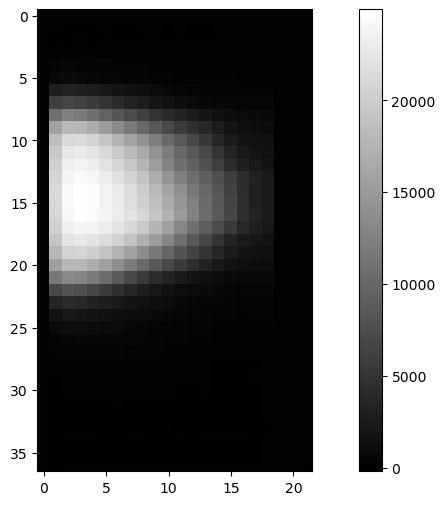

In [7]:
total_image = np.sum(image_data,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

# FITS Spectra

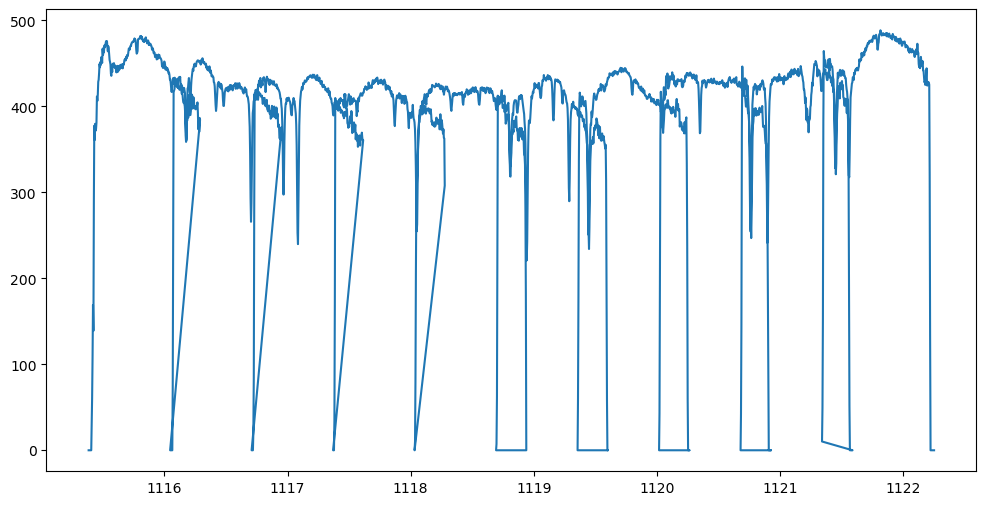

In [8]:
spectrum = np.sum(np.sum(image_data[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792 #summed over subset of x and y on disk of Venus to get spectrum

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wavenumber,spectrum)

plt.show()

In [55]:
spectrum = np.sum(np.sum(image_data[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump=sky*600

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits Files",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,
    x_axis_label="Wavenumber (cm^(-1))",
    y_axis_label="Intensity")

q.line(wavenumber, spectrum, legend_label='Venus', color='red')
q.line(wavenumber, sky_bump,legend_label='Sky', color='green')

q.legend.location = "bottom_right"

show(q)

# PSG Spectra

## Region One:

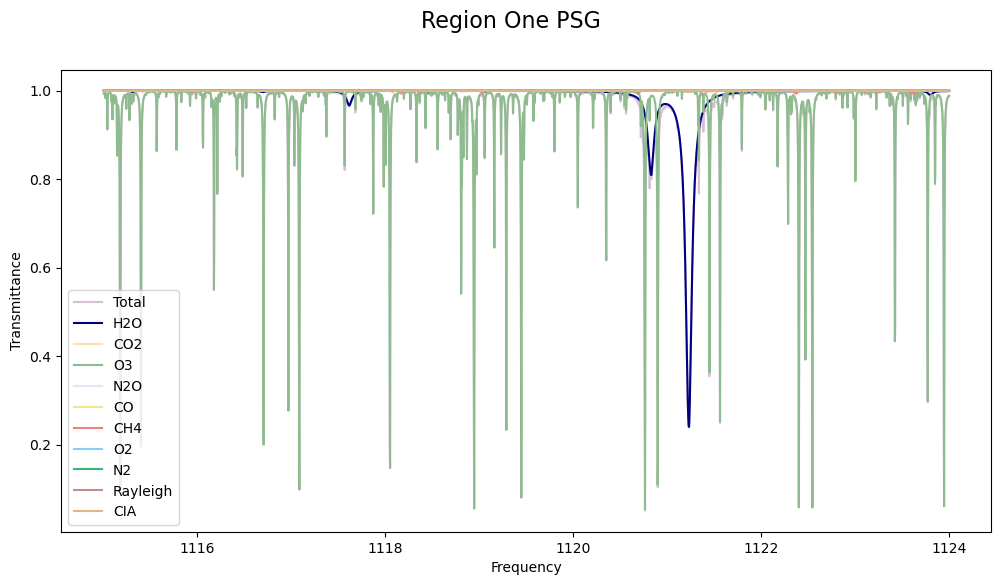

In [10]:
R1_model_wavenumber = []
R1_total_spectrum = []
R1_H2O_spectrum = []
R1_CO2_spectrum = []
R1_O3_spectrum = []
R1_N2O_spectrum = []
R1_CO_spectrum = []
R1_CH4_spectrum = []
R1_O2_spectrum = []
R1_N2_spectrum = []
R1_Rayleigh_spectrum = []
R1_CIA_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - R1_PSG addition.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        R1_model_wavenumber.append(float(row[0]))
        R1_total_spectrum.append(float(row[1]))
        R1_H2O_spectrum.append(float(row[2]))
        R1_CO2_spectrum.append(float(row[3]))
        R1_O3_spectrum.append(float(row[4]))
        R1_N2O_spectrum.append(float(row[5]))
        R1_CO_spectrum.append(float(row[6]))
        R1_CH4_spectrum.append(float(row[7]))
        R1_O2_spectrum.append(float(row[8]))
        R1_N2_spectrum.append(float(row[9]))
        R1_Rayleigh_spectrum.append(float(row[10]))
        R1_CIA_spectrum.append(float(row[11]))
        
fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Region One PSG', fontsize=16)


ax.plot(R1_model_wavenumber,R1_total_spectrum, label = 'Total', color='thistle')
ax.plot(R1_model_wavenumber,R1_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(R1_model_wavenumber,R1_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(R1_model_wavenumber,R1_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(R1_model_wavenumber,R1_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(R1_model_wavenumber,R1_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(R1_model_wavenumber,R1_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(R1_model_wavenumber,R1_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(R1_model_wavenumber,R1_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(R1_model_wavenumber,R1_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(R1_model_wavenumber,R1_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show()        

In [11]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Region One PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_model_wavenumber, R1_total_spectrum, legend_label='Earth', color='thistle') #consists of H2O, O3, N2O, and CH4
q.line(R1_model_wavenumber, R1_H2O_spectrum,legend_label='H2O', color='navy') #three features present
q.line(R1_model_wavenumber, R1_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(R1_model_wavenumber, R1_O3_spectrum,legend_label='O3', color='darkseagreen') #primariliy present
q.line(R1_model_wavenumber, R1_N2O_spectrum,legend_label='N2O', color='lavender') #largely present
q.line(R1_model_wavenumber, R1_CO_spectrum,legend_label='CO', color='khaki') 
q.line(R1_model_wavenumber, R1_CH4_spectrum,legend_label='CH4', color='lightcoral') #present 
q.line(R1_model_wavenumber, R1_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(R1_model_wavenumber, R1_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(R1_model_wavenumber, R1_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(R1_model_wavenumber, R1_CIA_spectrum,legend_label='CIA', color='burlywood')


q.legend.location = "bottom_right"

show(q)



## Region Two:

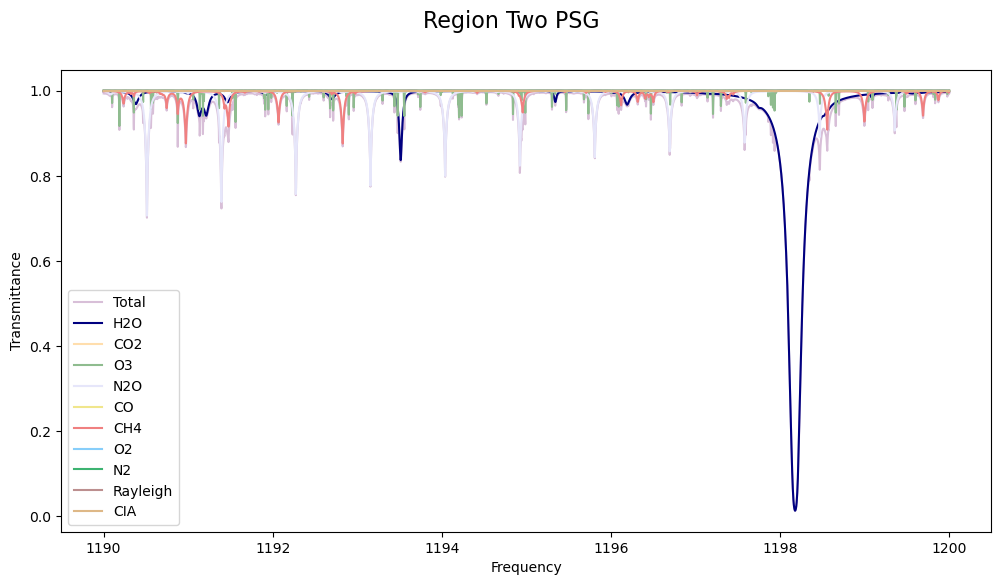

In [12]:
R2_model_wavenumber = []
R2_total_spectrum = []
R2_H2O_spectrum = []
R2_CO2_spectrum = []
R2_O3_spectrum = []
R2_N2O_spectrum = []
R2_CO_spectrum = []
R2_CH4_spectrum = []
R2_O2_spectrum = []
R2_N2_spectrum = []
R2_Rayleigh_spectrum = []
R2_CIA_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - R2_PSG.csv') as r2_psg_file:  
    plots = csv.reader(r2_psg_file, delimiter = ',') 
      
    for row in plots: 
        R2_model_wavenumber.append(float(row[0]))
        R2_total_spectrum.append(float(row[1]))
        R2_H2O_spectrum.append(float(row[2]))
        R2_CO2_spectrum.append(float(row[3]))
        R2_O3_spectrum.append(float(row[4]))
        R2_N2O_spectrum.append(float(row[5]))
        R2_CO_spectrum.append(float(row[6]))
        R2_CH4_spectrum.append(float(row[7]))
        R2_O2_spectrum.append(float(row[8]))
        R2_N2_spectrum.append(float(row[9]))
        R2_Rayleigh_spectrum.append(float(row[10]))
        R2_CIA_spectrum.append(float(row[11]))

fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Region Two PSG', fontsize=16)


ax.plot(R2_model_wavenumber,R2_total_spectrum, label = 'Total', color='thistle')
ax.plot(R2_model_wavenumber,R2_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(R2_model_wavenumber,R2_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(R2_model_wavenumber,R2_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(R2_model_wavenumber,R2_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(R2_model_wavenumber,R2_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(R2_model_wavenumber,R2_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(R2_model_wavenumber,R2_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(R2_model_wavenumber,R2_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(R2_model_wavenumber,R2_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(R2_model_wavenumber,R2_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show() 

In [13]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Region Two PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_model_wavenumber, R2_total_spectrum, legend_label='Earth', color='thistle')
q.line(R2_model_wavenumber, R2_H2O_spectrum,legend_label='H2O', color='navy')
q.line(R2_model_wavenumber, R2_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(R2_model_wavenumber, R2_O3_spectrum,legend_label='O3', color='darkseagreen')
q.line(R2_model_wavenumber, R2_N2O_spectrum,legend_label='N2O', color='lavender')
q.line(R2_model_wavenumber, R2_CO_spectrum,legend_label='CO', color='khaki')
q.line(R2_model_wavenumber, R2_CH4_spectrum,legend_label='CH4', color='lightcoral')
q.line(R2_model_wavenumber, R2_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(R2_model_wavenumber, R2_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(R2_model_wavenumber, R2_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(R2_model_wavenumber, R2_CIA_spectrum,legend_label='CIA', color='burlywood')


q.legend.location = "bottom_right"

show(q)

# Data Processing

## Separating Orders

In [14]:
order_array = np.zeros(len(wavenumber))
order_count = 1
for i in range(len(wavenumber)):
     if i == 0:
          order_array[i] = order_count
     else:
          if wavenumber[i] < wavenumber[i-1]:
               order_count = order_count+1
               order_array[i] = order_count
          else:
               order_array[i] = order_count

print(order_count)
print(len(order_array))
print(order_array[1:2560])

10
2560
[ 1.  1.  1. ... 10. 10. 10.]


### Region One (will not work if Region Two File is Loaded)

#### Parameters

In [15]:
R1_exp_H2O = 0.45 #exponent on water transmission
R1_exp_O3 = 0.5 #exponent on CO2 transmission
R1_exp_N2O = 0.3 #exponent on CH4 transmission
R1_exp_CH4 = 0.3 #exponent on CH4 transmission

R1_k = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift = 0.4 #empirical wavenumber shift to improve residuals

#### Order One

In [16]:
R1_o1_wavenumber = wavenumber[0:256]
R1_o1_spectrum = spectrum[0:256]
R1_o1_min = R1_o1_wavenumber[0]
#print(R1_o1_min)
R1_o1_max = R1_o1_wavenumber[255]
#print(R1_o1_max)
#print(R1_o1_wavenumber)

R1_reversed = list(reversed(R1_model_wavenumber))
R1_o1_index_min = (np.abs(R1_reversed - R1_o1_min)).argmin() - 2
#print(R1_o1_index_min)
#print(R1_reversed[R1_o1_index_min])
R1_o1_index_max = (np.abs(R1_reversed - R1_o1_max)).argmin() + 2
#print(R1_o1_index_max)
#print(R1_reversed[R1_o1_index_max])
R1_o1_model_wavenumber = R1_reversed[R1_o1_index_min:R1_o1_index_max]
#print(o1_wavenumber)

R1_H2O_reversed = list(reversed(R1_H2O_spectrum))
R1_O3_reversed = list(reversed(R1_O3_spectrum))
R1_N2O_reversed = list(reversed(R1_N2O_spectrum))
R1_CH4_reversed = list(reversed(R1_CH4_spectrum))
R1_o1_H2O = R1_H2O_reversed[R1_o1_index_min:R1_o1_index_max]
R1_o1_O3 = R1_O3_reversed[R1_o1_index_min:R1_o1_index_max]
R1_o1_N2O = R1_N2O_reversed[R1_o1_index_min:R1_o1_index_max]
R1_o1_CH4 = R1_CH4_reversed[R1_o1_index_min:R1_o1_index_max]

R1_o1_sky = sky[0:256]
R1_o1_sky_bump = R1_o1_sky / np.median(R1_o1_sky)

In [17]:
R1_o1_H2O_exp=[]
R1_o1_O3_exp=[]
R1_o1_N2O_exp=[]
R1_o1_CH4_exp=[]
for number in R1_o1_H2O:
    R1_o1_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o1_O3:
    R1_o1_O3_exp.append(number**R1_exp_O3)
for number in R1_o1_N2O:
    R1_o1_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o1_CH4:
    R1_o1_CH4_exp.append(number**R1_exp_CH4)

R1_o1_total = np.array(R1_o1_H2O_exp)*np.array(R1_o1_O3_exp)*np.array(R1_o1_N2O_exp)*np.array(R1_o1_CH4_exp)

R1_o1_gaussian = gaussian_filter(R1_o1_total,R1_k)

R1_o1_interpolate = scipy.interpolate.interp1d(R1_o1_model_wavenumber, R1_o1_gaussian)
R1_o1_interpolate_function = R1_o1_interpolate(R1_o1_wavenumber)

R1_o1_telluric = scipy.ndimage.shift(R1_o1_interpolate_function, R1_wavenumber_shift)
R1_o1_normalized_telluric = R1_o1_telluric / np.median(R1_o1_telluric)


R1_o1_normalized_spectrum = R1_o1_spectrum / np.median(R1_o1_spectrum)
R1_o1_processed_spectrum = np.divide(R1_o1_normalized_spectrum, R1_o1_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/847051424.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o1_processed_spectrum = np.divide(R1_o1_normalized_spectrum, R1_o1_telluric)


In [18]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o1_wavenumber, R1_o1_normalized_telluric, legend_label='order one corrected telluric', color='orange')
q.line(R1_o1_wavenumber, R1_o1_processed_spectrum, legend_label='order one venus processed', color='green')
q.line(R1_o1_wavenumber, R1_o1_normalized_spectrum, legend_label='order one venus unprocessed', color='red')
q.line(R1_o1_wavenumber, R1_o1_sky_bump,legend_label='order one sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Two

In [19]:
R1_o2_wavenumber = wavenumber[256:512]
R1_o2_spectrum = spectrum[256:512]
R1_o2_min = R1_o2_wavenumber[0]
#print(R1_o2_min)
R1_o2_max = R1_o2_wavenumber[255]
#print(R1_o2_max)
#print(R1_o2_wavenumber)

R1_o2_index_min = (np.abs(R1_reversed - R1_o2_min)).argmin() - 2
#print(R1_o2_index_min)
#print(R1_reversed[R1_o2_index_min])
R1_o2_index_max = (np.abs(R1_reversed - R1_o2_max)).argmin() + 2
#print(R1_o2_index_max)
#print(R1_reversed[R1_o2_index_max])
R1_o2_model_wavenumber = R1_reversed[R1_o2_index_min:R1_o2_index_max]
#print(R1_o2_wavenumber)

R1_o2_H2O = R1_H2O_reversed[R1_o2_index_min:R1_o2_index_max]
R1_o2_O3 = R1_O3_reversed[R1_o2_index_min:R1_o2_index_max]
R1_o2_N2O = R1_N2O_reversed[R1_o2_index_min:R1_o2_index_max]
R1_o2_CH4 = R1_CH4_reversed[R1_o2_index_min:R1_o2_index_max]

R1_o2_sky = sky[256:512]
R1_o2_sky_bump = R1_o2_sky / np.median(R1_o2_sky)

In [20]:
R1_o2_H2O_exp=[]
R1_o2_O3_exp=[]
R1_o2_N2O_exp=[]
R1_o2_CH4_exp=[]
for number in R1_o2_H2O:
    R1_o2_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o2_O3:
    R1_o2_O3_exp.append(number**R1_exp_O3)
for number in R1_o2_N2O:
    R1_o2_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o2_CH4:
    R1_o2_CH4_exp.append(number**R1_exp_CH4)

R1_o2_total = np.array(R1_o2_H2O_exp)*np.array(R1_o2_O3_exp)*np.array(R1_o2_N2O_exp)*np.array(R1_o2_CH4_exp)

R1_o2_gaussian = gaussian_filter(R1_o2_total,R1_k)

R1_o2_interpolate = scipy.interpolate.interp1d(R1_o2_model_wavenumber, R1_o2_gaussian)
R1_o2_interpolate_function = R1_o2_interpolate(R1_o2_wavenumber)

R1_o2_telluric = scipy.ndimage.shift(R1_o2_interpolate_function, R1_wavenumber_shift)
R1_o2_normalized_telluric = R1_o2_telluric / np.median(R1_o2_telluric)

R1_o2_normalized_spectrum = R1_o2_spectrum / np.median(R1_o2_spectrum)
R1_o2_processed_spectrum = np.divide(R1_o2_normalized_spectrum, R1_o2_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/1444034504.py:25: RuntimeWarning: invalid value encountered in divide
  R1_o2_processed_spectrum = np.divide(R1_o2_normalized_spectrum, R1_o2_telluric)


In [21]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o2_wavenumber, R1_o2_normalized_telluric, legend_label='order two corrected telluric', color='orange')
q.line(R1_o2_wavenumber, R1_o2_processed_spectrum, legend_label='order two venus processed', color='green')
q.line(R1_o2_wavenumber, R1_o2_normalized_spectrum, legend_label='order two venus unprocessed', color='red')
q.line(R1_o2_wavenumber, R1_o2_sky_bump,legend_label='order two sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Three

In [22]:
R1_o3_wavenumber = wavenumber[512:768]
R1_o3_spectrum = spectrum[512:768]
R1_o3_min = R1_o3_wavenumber[0]
#print(R1_o3_min)
R1_o3_max = R1_o3_wavenumber[255]
#print(R1_o3_max)
#print(R1_o3_wavenumber)

R1_o3_index_min = (np.abs(R1_reversed - R1_o3_min)).argmin() - 2
#print(R1_o3_index_min)
#print(R1_reversed[R1_o3_index_min])
R1_o3_index_max = (np.abs(R1_reversed - R1_o3_max)).argmin() + 2
#print(R1_o3_index_max)
#print(R1_reversed[R1_o3_index_max])
R1_o3_model_wavenumber = R1_reversed[R1_o3_index_min:R1_o3_index_max]
#print(R1_o3_wavenumber)

R1_o3_H2O = R1_H2O_reversed[R1_o3_index_min:R1_o3_index_max]
R1_o3_O3 = R1_O3_reversed[R1_o3_index_min:R1_o3_index_max]
R1_o3_N2O = R1_N2O_reversed[R1_o3_index_min:R1_o3_index_max]
R1_o3_CH4 = R1_CH4_reversed[R1_o3_index_min:R1_o3_index_max]

R1_o3_sky = sky[512:768]
R1_o3_sky_bump = R1_o3_sky / np.median(R1_o3_sky)

In [23]:
R1_o3_H2O_exp=[]
R1_o3_O3_exp=[]
R1_o3_N2O_exp=[]
R1_o3_CH4_exp=[]
for number in R1_o3_H2O:
    R1_o3_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o3_O3:
    R1_o3_O3_exp.append(number**R1_exp_O3)
for number in R1_o3_N2O:
    R1_o3_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o3_CH4:
    R1_o3_CH4_exp.append(number**R1_exp_CH4)

R1_o3_total = np.array(R1_o3_H2O_exp)*np.array(R1_o3_O3_exp)*np.array(R1_o3_N2O_exp)*np.array(R1_o3_CH4_exp)

R1_o3_gaussian = gaussian_filter(R1_o3_total,R1_k)

R1_o3_interpolate = scipy.interpolate.interp1d(R1_o3_model_wavenumber, R1_o3_gaussian)
R1_o3_interpolate_function = R1_o3_interpolate(R1_o3_wavenumber)

R1_o3_telluric = scipy.ndimage.shift(R1_o3_interpolate_function, R1_wavenumber_shift)
R1_o3_normalized_telluric = R1_o3_telluric / np.median(R1_o3_telluric)


R1_o3_normalized_spectrum = R1_o3_spectrum / np.median(R1_o3_spectrum)
R1_o3_processed_spectrum = np.divide(R1_o3_normalized_spectrum, R1_o3_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/986771266.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o3_processed_spectrum = np.divide(R1_o3_normalized_spectrum, R1_o3_telluric)


In [24]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o3_wavenumber, R1_o3_normalized_telluric, legend_label='order three corrected telluric', color='orange')
q.line(R1_o3_wavenumber, R1_o3_processed_spectrum, legend_label='order three venus processed', color='green')
q.line(R1_o3_wavenumber, R1_o3_normalized_spectrum, legend_label='order three venus unprocessed', color='red')
q.line(R1_o3_wavenumber, R1_o3_sky_bump,legend_label='order three sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Four

In [25]:
R1_o4_wavenumber = wavenumber[768:1024]
R1_o4_spectrum = spectrum[768:1024]
R1_o4_min = R1_o4_wavenumber[0]
#print(R1_o4_min)
R1_o4_max = R1_o4_wavenumber[255]
#print(R1_o4_max)
#print(R1_o4_wavenumber)

R1_o4_index_min = (np.abs(R1_reversed - R1_o4_min)).argmin() - 2
#print(R1_o4_index_min)
#print(R1_reversed[R1_o4_index_min])
R1_o4_index_max = (np.abs(R1_reversed - R1_o4_max)).argmin() + 2
#print(R1_o4_index_max)
#print(R1_reversed[R1_o4_index_max])
R1_o4_model_wavenumber = R1_reversed[R1_o4_index_min:R1_o4_index_max]
#print(R1_o4_wavenumber)

R1_o4_H2O = R1_H2O_reversed[R1_o4_index_min:R1_o4_index_max]
R1_o4_O3 = R1_O3_reversed[R1_o4_index_min:R1_o4_index_max]
R1_o4_N2O = R1_N2O_reversed[R1_o4_index_min:R1_o4_index_max]
R1_o4_CH4 = R1_CH4_reversed[R1_o4_index_min:R1_o4_index_max]

R1_o4_sky = sky[768:1024]
R1_o4_sky_bump = R1_o4_sky / np.median(R1_o4_sky)

In [26]:
R1_o4_H2O_exp=[]
R1_o4_O3_exp=[]
R1_o4_N2O_exp=[]
R1_o4_CH4_exp=[]
for number in R1_o4_H2O:
    R1_o4_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o4_O3:
    R1_o4_O3_exp.append(number**R1_exp_O3)
for number in R1_o4_N2O:
    R1_o4_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o4_CH4:
    R1_o4_CH4_exp.append(number**R1_exp_CH4)

R1_o4_total = np.array(R1_o4_H2O_exp)*np.array(R1_o4_O3_exp)*np.array(R1_o4_N2O_exp)*np.array(R1_o4_CH4_exp)

R1_o4_gaussian = gaussian_filter(R1_o4_total,R1_k)

R1_o4_interpolate = scipy.interpolate.interp1d(R1_o4_model_wavenumber, R1_o4_gaussian)
R1_o4_interpolate_function = R1_o4_interpolate(R1_o4_wavenumber)

R1_o4_telluric = shift(R1_o4_interpolate_function, R1_wavenumber_shift)
R1_o4_normalized_telluric = R1_o4_telluric / np.median(R1_o4_telluric)


R1_o4_normalized_spectrum = R1_o4_spectrum / np.median(R1_o4_spectrum)
R1_o4_processed_spectrum = np.divide(R1_o4_normalized_spectrum, R1_o4_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/3541379235.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o4_processed_spectrum = np.divide(R1_o4_normalized_spectrum, R1_o4_telluric)


In [27]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Four",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o4_wavenumber, R1_o4_normalized_telluric, legend_label='order four corrected telluric', color='orange')
q.line(R1_o4_wavenumber, R1_o4_processed_spectrum, legend_label='order four venus processed', color='green')
q.line(R1_o4_wavenumber, R1_o4_normalized_spectrum, legend_label='order four venus unprocessed', color='red')
q.line(R1_o4_wavenumber, R1_o4_sky_bump,legend_label='order four sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Five

In [28]:
R1_o5_wavenumber = wavenumber[1024:1280]
R1_o5_spectrum = spectrum[1024:1280]
R1_o5_min = R1_o5_wavenumber[0]
#print(R1_o5_min)
R1_o5_max = R1_o5_wavenumber[255]
#print(R1_o5_max)
#print(R1_o5_wavenumber)

R1_o5_index_min = (np.abs(R1_reversed - R1_o5_min)).argmin() - 2
#print(R1_o5_index_min)
#print(R1_reversed[R1_o5_index_min])
R1_o5_index_max = (np.abs(R1_reversed - R1_o5_max)).argmin() + 2
#print(R1_o5_index_max)
#print(R1_reversed[R1_o5_index_max])
R1_o5_model_wavenumber = R1_reversed[R1_o5_index_min:R1_o5_index_max]
#print(R1_o5_wavenumber)

R1_o5_H2O = R1_H2O_reversed[R1_o5_index_min:R1_o5_index_max]
R1_o5_O3 = R1_O3_reversed[R1_o5_index_min:R1_o5_index_max]
R1_o5_N2O = R1_N2O_reversed[R1_o5_index_min:R1_o5_index_max]
R1_o5_CH4 = R1_CH4_reversed[R1_o5_index_min:R1_o5_index_max]

R1_o5_sky = sky[1024:1280]
R1_o5_sky_bump = R1_o5_sky / np.median(R1_o5_sky)

In [29]:
R1_o5_H2O_exp=[]
R1_o5_O3_exp=[]
R1_o5_N2O_exp=[]
R1_o5_CH4_exp=[]
for number in R1_o5_H2O:
    R1_o5_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o5_O3:
    R1_o5_O3_exp.append(number**R1_exp_O3)
for number in R1_o5_N2O:
    R1_o5_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o5_CH4:
    R1_o5_CH4_exp.append(number**R1_exp_CH4)

R1_o5_total = np.array(R1_o5_H2O_exp)*np.array(R1_o5_O3_exp)*np.array(R1_o5_N2O_exp)*np.array(R1_o5_CH4_exp)

R1_o5_gaussian = gaussian_filter(R1_o5_total,R1_k)

R1_o5_interpolate = scipy.interpolate.interp1d(R1_o5_model_wavenumber, R1_o5_gaussian)
R1_o5_interpolate_function = R1_o5_interpolate(R1_o5_wavenumber)

R1_o5_telluric = shift(R1_o5_interpolate_function, R1_wavenumber_shift)
R1_o5_normalized_telluric = R1_o5_telluric / np.median(R1_o5_telluric)


R1_o5_normalized_spectrum = R1_o5_spectrum / np.median(R1_o5_spectrum)
R1_o5_processed_spectrum = np.divide(R1_o5_normalized_spectrum, R1_o5_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/2862324589.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o5_processed_spectrum = np.divide(R1_o5_normalized_spectrum, R1_o5_telluric)


In [30]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Five",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o5_wavenumber, R1_o5_normalized_telluric, legend_label='order five corrected telluric', color='orange')
q.line(R1_o5_wavenumber, R1_o5_processed_spectrum, legend_label='order five venus processed', color='green')
q.line(R1_o5_wavenumber, R1_o5_normalized_spectrum, legend_label='order five venus unprocessed', color='red')
q.line(R1_o5_wavenumber, R1_o5_sky_bump,legend_label='order five sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Six

In [31]:
R1_o6_wavenumber = wavenumber[1280:1536]
R1_o6_spectrum = spectrum[1280:1536]
R1_o6_min = R1_o6_wavenumber[0]
#print(R1_o6_min)
R1_o6_max = R1_o6_wavenumber[255]
#print(R1_o6_max)
#print(R1_o6_wavenumber)

R1_o6_index_min = (np.abs(R1_reversed - R1_o6_min)).argmin() - 2
#print(R1_o6_index_min)
#print(R1_reversed[R1_o6_index_min])
R1_o6_index_max = (np.abs(R1_reversed - R1_o6_max)).argmin() + 2
#print(R1_o6_index_max)
#print(R1_reversed[R1_o6_index_max])
R1_o6_model_wavenumber = R1_reversed[R1_o6_index_min:R1_o6_index_max]
#print(R1_o6_wavenumber)

R1_o6_H2O = R1_H2O_reversed[R1_o6_index_min:R1_o6_index_max]
R1_o6_O3 = R1_O3_reversed[R1_o6_index_min:R1_o6_index_max]
R1_o6_N2O = R1_N2O_reversed[R1_o6_index_min:R1_o6_index_max]
R1_o6_CH4 = R1_CH4_reversed[R1_o6_index_min:R1_o6_index_max]

R1_o6_sky = sky[1280:1536]
R1_o6_sky_bump = R1_o6_sky / np.median(R1_o6_sky)

In [32]:
R1_o6_H2O_exp=[]
R1_o6_O3_exp=[]
R1_o6_N2O_exp=[]
R1_o6_CH4_exp=[]
for number in R1_o6_H2O:
    R1_o6_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o6_O3:
    R1_o6_O3_exp.append(number**R1_exp_O3)
for number in R1_o6_N2O:
    R1_o6_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o6_CH4:
    R1_o6_CH4_exp.append(number**R1_exp_CH4)

R1_o6_total = np.array(R1_o6_H2O_exp)*np.array(R1_o6_O3_exp)*np.array(R1_o6_N2O_exp)*np.array(R1_o6_CH4_exp)

R1_o6_gaussian = gaussian_filter(R1_o6_total,R1_k)

R1_o6_interpolate = scipy.interpolate.interp1d(R1_o6_model_wavenumber, R1_o6_gaussian)
R1_o6_interpolate_function = R1_o6_interpolate(R1_o6_wavenumber)

R1_o6_telluric = shift(R1_o6_interpolate_function, R1_wavenumber_shift)
R1_o6_normalized_telluric = R1_o6_telluric / np.median(R1_o6_telluric)


R1_o6_normalized_spectrum = R1_o6_spectrum / np.median(R1_o6_spectrum)
R1_o6_processed_spectrum = np.divide(R1_o6_normalized_spectrum, R1_o6_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/2455881052.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o6_processed_spectrum = np.divide(R1_o6_normalized_spectrum, R1_o6_telluric)


In [33]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o6_wavenumber, R1_o6_normalized_telluric, legend_label='order six corrected telluric', color='orange')
q.line(R1_o6_wavenumber, R1_o6_processed_spectrum, legend_label='order six venus processed', color='green')
q.line(R1_o6_wavenumber, R1_o6_normalized_spectrum, legend_label='order six venus unprocessed', color='red')
q.line(R1_o6_wavenumber, R1_o6_sky_bump,legend_label='order six sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Seven

In [34]:
R1_o7_wavenumber = wavenumber[1536:1792]
R1_o7_spectrum = spectrum[1536:1792]
R1_o7_min = R1_o7_wavenumber[0]
#print(R1_o7_min)
R1_o7_max = R1_o7_wavenumber[255]
#print(R1_o7_max)
#print(R1_o7_wavenumber)

R1_o7_index_min = (np.abs(R1_reversed - R1_o7_min)).argmin() - 2
#print(R1_o7_index_min)
#print(R1_reversed[R1_o7_index_min])
R1_o7_index_max = (np.abs(R1_reversed - R1_o7_max)).argmin() + 2
#print(R1_o7_index_max)
#print(R1_reversed[R1_o7_index_max])
R1_o7_model_wavenumber = R1_reversed[R1_o7_index_min:R1_o7_index_max]
#print(R1_o7_wavenumber)

R1_o7_H2O = R1_H2O_reversed[R1_o7_index_min:R1_o7_index_max]
R1_o7_O3 = R1_O3_reversed[R1_o7_index_min:R1_o7_index_max]
R1_o7_N2O = R1_N2O_reversed[R1_o7_index_min:R1_o7_index_max]
R1_o7_CH4 = R1_CH4_reversed[R1_o7_index_min:R1_o7_index_max]

R1_o7_sky = sky[1536:1792]
R1_o7_sky_bump = R1_o7_sky / np.median(R1_o7_sky)

In [35]:
R1_o7_H2O_exp=[]
R1_o7_O3_exp=[]
R1_o7_N2O_exp=[]
R1_o7_CH4_exp=[]
for number in R1_o7_H2O:
    R1_o7_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o7_O3:
    R1_o7_O3_exp.append(number**R1_exp_O3)
for number in R1_o7_N2O:
    R1_o7_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o7_CH4:
    R1_o7_CH4_exp.append(number**R1_exp_CH4)

R1_o7_total = np.array(R1_o7_H2O_exp)*np.array(R1_o7_O3_exp)*np.array(R1_o7_N2O_exp)*np.array(R1_o7_CH4_exp)

R1_o7_gaussian = gaussian_filter(R1_o7_total,R1_k)

R1_o7_interpolate = scipy.interpolate.interp1d(R1_o7_model_wavenumber, R1_o7_gaussian)
R1_o7_interpolate_function = R1_o7_interpolate(R1_o7_wavenumber)

R1_o7_telluric = shift(R1_o7_interpolate_function, R1_wavenumber_shift)
R1_o7_normalized_telluric = R1_o7_telluric / np.median(R1_o7_telluric)


R1_o7_normalized_spectrum = R1_o7_spectrum / np.median(R1_o7_spectrum)
R1_o7_processed_spectrum = np.divide(R1_o7_normalized_spectrum, R1_o7_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/2137326527.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o7_processed_spectrum = np.divide(R1_o7_normalized_spectrum, R1_o7_telluric)


In [36]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Seven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o7_wavenumber, R1_o7_normalized_telluric, legend_label='order seven corrected telluric', color='orange')
q.line(R1_o7_wavenumber, R1_o7_processed_spectrum, legend_label='order seven venus processed', color='green')
q.line(R1_o7_wavenumber, R1_o7_normalized_spectrum, legend_label='order seven venus unprocessed', color='red')
q.line(R1_o7_wavenumber, R1_o7_sky_bump,legend_label='order seven sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Eight

In [37]:
R1_o8_wavenumber = wavenumber[1792:2048]
R1_o8_spectrum = spectrum[1792:2048]
R1_o8_min = R1_o8_wavenumber[0]
#print(R1_o8_min)
R1_o8_max = R1_o8_wavenumber[255]
#print(R1_o8_max)
#print(R1_o8_wavenumber)

R1_o8_index_min = (np.abs(R1_reversed - R1_o8_min)).argmin() - 2
#print(R1_o8_index_min)
#print(R1_reversed[R1_o8_index_min])
R1_o8_index_max = (np.abs(R1_reversed - R1_o8_max)).argmin() + 2
#print(R1_o8_index_max)
#print(R1_reversed[R1_o8_index_max])
R1_o8_model_wavenumber = R1_reversed[R1_o8_index_min:R1_o8_index_max]
#print(R1_o8_wavenumber)

R1_o8_H2O = R1_H2O_reversed[R1_o8_index_min:R1_o8_index_max]
R1_o8_O3 = R1_O3_reversed[R1_o8_index_min:R1_o8_index_max]
R1_o8_N2O = R1_N2O_reversed[R1_o8_index_min:R1_o8_index_max]
R1_o8_CH4 = R1_CH4_reversed[R1_o8_index_min:R1_o8_index_max]

R1_o8_sky = sky[1792:2048]
R1_o8_sky_bump = R1_o8_sky / np.median(R1_o8_sky)

In [38]:
R1_o8_H2O_exp=[]
R1_o8_O3_exp=[]
R1_o8_N2O_exp=[]
R1_o8_CH4_exp=[]
for number in R1_o8_H2O:
    R1_o8_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o8_O3:
    R1_o8_O3_exp.append(number**R1_exp_O3)
for number in R1_o8_N2O:
    R1_o8_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o8_CH4:
    R1_o8_CH4_exp.append(number**R1_exp_CH4)

R1_o8_total = np.array(R1_o8_H2O_exp)*np.array(R1_o8_O3_exp)*np.array(R1_o8_N2O_exp)*np.array(R1_o8_CH4_exp)

R1_o8_gaussian = gaussian_filter(R1_o8_total,R1_k)

R1_o8_interpolate = scipy.interpolate.interp1d(R1_o8_model_wavenumber, R1_o8_gaussian)
R1_o8_interpolate_function = R1_o8_interpolate(R1_o8_wavenumber)

R1_o8_telluric = shift(R1_o8_interpolate_function, R1_wavenumber_shift)
R1_o8_normalized_telluric = R1_o8_telluric / np.median(R1_o8_telluric)


R1_o8_normalized_spectrum = R1_o8_spectrum / np.median(R1_o8_spectrum)
R1_o8_processed_spectrum = np.divide(R1_o8_normalized_spectrum, R1_o8_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/2175482159.py:26: RuntimeWarning: invalid value encountered in divide
  R1_o8_processed_spectrum = np.divide(R1_o8_normalized_spectrum, R1_o8_telluric)


In [39]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Eight",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o8_wavenumber, R1_o8_normalized_telluric, legend_label='order eight corrected telluric', color='orange')
q.line(R1_o8_wavenumber, R1_o8_processed_spectrum, legend_label='order eight venus processed', color='green')
q.line(R1_o8_wavenumber, R1_o8_normalized_spectrum, legend_label='order eight venus unprocessed', color='red')
q.line(R1_o8_wavenumber, R1_o8_sky_bump,legend_label='order eight sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Nine

In [40]:
R1_o9_wavenumber = wavenumber[2048:2304]
R1_o9_spectrum = spectrum[2048:2304]
R1_o9_min = R1_o9_wavenumber[0]
#print(R1_o9_min)
R1_o9_max = R1_o9_wavenumber[255]
#print(R1_o9_max)
#print(R1_o9_wavenumber)

R1_o9_index_min = (np.abs(R1_reversed - R1_o9_min)).argmin() - 2
#print(R1_o9_index_min)
#print(R1_reversed[R1_o9_index_min])
R1_o9_index_max = (np.abs(R1_reversed - R1_o9_max)).argmin() + 2
#print(R1_o9_index_max)
#print(R1_reversed[R1_o9_index_max])
R1_o9_model_wavenumber = R1_reversed[R1_o9_index_min:R1_o9_index_max]
#print(R1_o9_wavenumber)

R1_o9_H2O = R1_H2O_reversed[R1_o9_index_min:R1_o9_index_max]
R1_o9_O3 = R1_O3_reversed[R1_o9_index_min:R1_o9_index_max]
R1_o9_N2O = R1_N2O_reversed[R1_o9_index_min:R1_o9_index_max]
R1_o9_CH4 = R1_CH4_reversed[R1_o9_index_min:R1_o9_index_max]

R1_o9_sky = sky[2048:2304]
R1_o9_sky_bump = R1_o9_sky / np.median(R1_o9_sky)

In [41]:
R1_o9_H2O_exp=[]
R1_o9_O3_exp=[]
R1_o9_N2O_exp=[]
R1_o9_CH4_exp=[]
for number in R1_o9_H2O:
    R1_o9_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o9_O3:
    R1_o9_O3_exp.append(number**R1_exp_O3)
for number in R1_o9_N2O:
    R1_o9_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o9_CH4:
    R1_o9_CH4_exp.append(number**R1_exp_CH4)

R1_o9_total = np.array(R1_o9_H2O_exp)*np.array(R1_o9_O3_exp)*np.array(R1_o9_N2O_exp)*np.array(R1_o9_CH4_exp)

R1_o9_gaussian = gaussian_filter(R1_o9_total,R1_k)

R1_o9_interpolate = scipy.interpolate.interp1d(R1_o9_model_wavenumber, R1_o9_gaussian)
R1_o9_interpolate_function = R1_o9_interpolate(R1_o9_wavenumber)

R1_o9_telluric = shift(R1_o9_interpolate_function, R1_wavenumber_shift)
R1_o9_normalized_telluric = R1_o9_telluric / np.median(R1_o9_telluric)

R1_o9_normalized_spectrum = R1_o9_spectrum / np.median(R1_o9_spectrum)
R1_o9_processed_spectrum = np.divide(R1_o9_normalized_spectrum, R1_o9_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/599662762.py:25: RuntimeWarning: invalid value encountered in divide
  R1_o9_processed_spectrum = np.divide(R1_o9_normalized_spectrum, R1_o9_telluric)


In [42]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Nine",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o9_wavenumber, R1_o9_normalized_telluric, legend_label='order nine corrected telluric', color='orange')
q.line(R1_o9_wavenumber, R1_o9_processed_spectrum, legend_label='order nine venus processed', color='green')
q.line(R1_o9_wavenumber, R1_o9_normalized_spectrum, legend_label='order nine venus unprocessed', color='red')
q.line(R1_o9_wavenumber, R1_o9_sky_bump,legend_label='order nine sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Ten

In [43]:
R1_o10_wavenumber = wavenumber[2304:2560]
R1_o10_spectrum = spectrum[2304:2560]
R1_o10_min = R1_o10_wavenumber[0]
#print(R1_o10_min)
R1_o10_max = R1_o10_wavenumber[255]
#print(R1_o10_max)
#print(R1_o10_wavenumber)

R1_o10_index_min = (np.abs(R1_reversed - R1_o10_min)).argmin() - 2
#print(R1_o10_index_min)
#print(R1_reversed[R1_o10_index_min])
R1_o10_index_max = (np.abs(R1_reversed - R1_o10_max)).argmin() + 2
#print(R1_o10_index_max)
#print(R1_reversed[R1_o10_index_max])
R1_o10_model_wavenumber = R1_reversed[R1_o10_index_min:R1_o10_index_max]
#print(R1_o10_wavenumber)

R1_o10_H2O = R1_H2O_reversed[R1_o10_index_min:R1_o10_index_max]
R1_o10_O3 = R1_O3_reversed[R1_o10_index_min:R1_o10_index_max]
R1_o10_N2O = R1_N2O_reversed[R1_o10_index_min:R1_o10_index_max]
R1_o10_CH4 = R1_CH4_reversed[R1_o10_index_min:R1_o10_index_max]
                             
R1_o10_sky = sky[2304:2560]
R1_o10_sky_bump = R1_o10_sky / np.median(R1_o10_sky)

In [44]:
R1_o10_H2O_exp=[]
R1_o10_O3_exp=[]
R1_o10_N2O_exp=[]
R1_o10_CH4_exp=[]
for number in R1_o10_H2O:
    R1_o10_H2O_exp.append(number**R1_exp_H2O)
for number in R1_o10_O3:
    R1_o10_O3_exp.append(number**R1_exp_O3)
for number in R1_o10_N2O:
    R1_o10_N2O_exp.append(number**R1_exp_N2O)
for number in R1_o10_CH4:
    R1_o10_CH4_exp.append(number**R1_exp_CH4)

R1_o10_total = np.array(R1_o10_H2O_exp)*np.array(R1_o10_O3_exp)*np.array(R1_o10_N2O_exp)*np.array(R1_o10_CH4_exp)

R1_o10_gaussian = gaussian_filter(R1_o10_total,R1_k)

R1_o10_interpolate = scipy.interpolate.interp1d(R1_o10_model_wavenumber, R1_o10_gaussian)
R1_o10_interpolate_function = R1_o10_interpolate(R1_o10_wavenumber)

R1_o10_telluric = shift(R1_o10_interpolate_function, R1_wavenumber_shift)
R1_o10_normalized_telluric = R1_o10_telluric / np.median(R1_o10_telluric)

R1_o10_normalized_spectrum = R1_o10_spectrum / np.median(R1_o10_spectrum)
R1_o10_processed_spectrum = np.divide(R1_o10_normalized_spectrum, R1_o10_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/690911287.py:25: RuntimeWarning: divide by zero encountered in divide
  R1_o10_processed_spectrum = np.divide(R1_o10_normalized_spectrum, R1_o10_telluric)


In [45]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Ten",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R1_o10_wavenumber, R1_o10_normalized_telluric, legend_label='order ten corrected telluric', color='orange')
q.line(R1_o10_wavenumber, R1_o10_processed_spectrum, legend_label='order ten venus processed', color='green')
q.line(R1_o10_wavenumber, R1_o10_normalized_spectrum, legend_label='order ten venus unprocessed', color='red')
q.line(R1_o10_wavenumber, R1_o10_sky_bump,legend_label='order ten sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Whole Spectrum

In [46]:
R1_H2O_exp=[]
R1_O3_exp=[]
R1_N2O_exp=[]
R1_CH4_exp=[]
for number in R1_H2O_reversed:
    R1_H2O_exp.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp.append(number**R1_exp_N2O)
for number in R1_CH4_reversed:
    R1_CH4_exp.append(number**R1_exp_CH4)

R1_total = np.array(R1_H2O_exp)*np.array(R1_O3_exp)*np.array(R1_N2O_exp)*np.array(R1_CH4_exp)

R1_gaussian = gaussian_filter(R1_total,R1_k)

R1_interpolate = scipy.interpolate.interp1d(R1_reversed, R1_gaussian)
R1_interpolate_function = R1_interpolate(wavenumber)

R1_telluric = shift(R1_interpolate_function, R1_wavenumber_shift)
R1_normalized_telluric = R1_telluric / np.median(R1_telluric)

R1_normalized_spectrum = spectrum / np.median(spectrum)
R1_processed_spectrum = np.divide(R1_normalized_spectrum, R1_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_13181/453782246.py:25: RuntimeWarning: invalid value encountered in divide
  R1_processed_spectrum = np.divide(R1_normalized_spectrum, R1_telluric)


In [47]:
sky_normalized = sky / np.median(sky)

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Whole Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber, R1_normalized_telluric, legend_label='corrected telluric', color='orange')
q.line(wavenumber, R1_processed_spectrum, legend_label='venus processed', color='green')
q.line(wavenumber, R1_normalized_spectrum, legend_label='venus unprocessed', color='red')
q.line(wavenumber, sky_normalized,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Region Two (will not work if Region One File is loaded)

#### Parameters

In [48]:
R2_exp_H2O = 0.2 #exponent on water transmission
R2_exp_O3 = 0.5 #exponent on CO2 transmission
R2_exp_N2O = 0.6 #exponent on CH4 transmission
R2_exp_CH4 = 0.5 #exponent on CH4 transmission

R2_k = 6 #Gaussian sigma of resolution broadening, in pixels

R2_wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

In [49]:
R2_reversed = list(reversed(R2_model_wavenumber))

R2_H2O_reversed = list(reversed(R2_H2O_spectrum))
R2_O3_reversed = list(reversed(R2_O3_spectrum))
R2_N2O_reversed = list(reversed(R2_N2O_spectrum))
R2_CH4_reversed = list(reversed(R2_CH4_spectrum))

#### Order One

In [50]:
R2_o1_wavenumber = wavenumber[0:256]
R2_o1_spectrum = spectrum[0:256]
R2_o1_min = R2_o1_wavenumber[0]
print(R2_o1_min)
R2_o1_max = R2_o1_wavenumber[255]
print(R2_o1_max)
#print(R1_o1_wavenumber)

R2_o1_index_min = (np.abs(R2_reversed - R2_o1_min)).argmin() - 2
#print(R2_o1_index_min)
#print(R2_reversed[R2_o1_index_min])
R2_o1_index_max = (np.abs(R2_reversed - R2_o1_max)).argmin() + 2
#print(R1_o1_index_max)
#print(R1_reversed[R1_o1_index_max])
R2_o1_model_wavenumber = R2_reversed[R2_o1_index_min:R2_o1_index_max]
#print(o1_wavenumber)

R2_o1_H2O = R2_H2O_reversed[R2_o1_index_min:R2_o1_index_max]
R2_o1_O3 = R2_O3_reversed[R2_o1_index_min:R2_o1_index_max]
R2_o1_N2O = R2_N2O_reversed[R2_o1_index_min:R2_o1_index_max]
R2_o1_CH4 = R2_CH4_reversed[R2_o1_index_min:R2_o1_index_max]

R2_o1_sky = sky[0:256]
R2_o1_sky_bump = R2_o1_sky / np.median(R2_o1_sky)

1115.3843
1116.2896


In [51]:
R2_o1_H2O_exp=[]
R2_o1_O3_exp=[]
R2_o1_N2O_exp=[]
R2_o1_CH4_exp=[]
for number in R2_o1_H2O:
    R2_o1_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o1_O3:
    R2_o1_O3_exp.append(number**R2_exp_O3)
for number in R2_o1_N2O:
    R2_o1_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o1_CH4:
    R2_o1_CH4_exp.append(number**R2_exp_CH4)

R2_o1_total = np.array(R2_o1_H2O_exp)*np.array(R2_o1_O3_exp)*np.array(R2_o1_N2O_exp)*np.array(R2_o1_CH4_exp)

R2_o1_gaussian = gaussian_filter(R2_o1_total,R2_k)

R2_o1_interpolate = scipy.interpolate.interp1d(R2_o1_model_wavenumber, R2_o1_gaussian)
R2_o1_interpolate_function = R2_o1_interpolate(R2_o1_wavenumber)

R2_o1_telluric = shift(R2_o1_interpolate_function, R2_wavenumber_shift)
R2_o1_normalized_telluric = R2_o1_telluric / np.median(R2_o1_telluric)


R2_o1_normalized_spectrum = R2_o1_spectrum / np.median(R2_o1_spectrum)
R2_o1_processed_spectrum = np.divide(R2_o1_normalized_spectrum, R2_o1_telluric)

ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o1_wavenumber, R2_o1_normalized_telluric, legend_label='order one corrected telluric', color='orange')
q.line(R2_o1_wavenumber, R2_o1_processed_spectrum, legend_label='order one venus processed', color='green')
q.line(R2_o1_wavenumber, R2_o1_normalized_spectrum, legend_label='order one venus unprocessed', color='red')
q.line(R2_o1_wavenumber, R2_o1_sky_bump,legend_label='order one sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Two

In [ ]:
R2_o2_wavenumber = wavenumber[256:512]
R2_o2_spectrum = spectrum[256:512]
R2_o2_min = R2_o2_wavenumber[0]
print(R2_o2_min)
R2_o2_max = R2_o2_wavenumber[255]
print(R2_o2_max)
#print(R1_o2_wavenumber)

R2_o2_index_min = (np.abs(R2_reversed - R2_o2_min)).argmin() - 2
#print(R2_o2_index_min)
#print(R2_reversed[R2_o2_index_min])
R2_o2_index_max = (np.abs(R2_reversed - R2_o2_max)).argmin() + 2
#print(R1_o2_index_max)
#print(R1_reversed[R1_o2_index_max])
R2_o2_model_wavenumber = R2_reversed[R2_o2_index_min:R2_o2_index_max]
#print(o1_wavenumber)

R2_o2_H2O = R2_H2O_reversed[R2_o2_index_min:R2_o2_index_max]
R2_o2_O3 = R2_O3_reversed[R2_o2_index_min:R2_o2_index_max]
R2_o2_N2O = R2_N2O_reversed[R2_o2_index_min:R2_o2_index_max]
R2_o2_CH4 = R2_CH4_reversed[R2_o2_index_min:R2_o2_index_max]

R2_o2_sky = sky[256:512]
R2_o2_sky_bump = R2_o2_sky / np.median(R2_o2_sky)

In [ ]:
R2_o2_H2O_exp=[]
R2_o2_O3_exp=[]
R2_o2_N2O_exp=[]
R2_o2_CH4_exp=[]
for number in R2_o2_H2O:
    R2_o2_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o2_O3:
    R2_o2_O3_exp.append(number**R2_exp_O3)
for number in R2_o2_N2O:
    R2_o2_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o2_CH4:
    R2_o2_CH4_exp.append(number**R2_exp_CH4)

R2_o2_total = np.array(R2_o2_H2O_exp)*np.array(R2_o2_O3_exp)*np.array(R2_o2_N2O_exp)*np.array(R2_o2_CH4_exp)

R2_o2_gaussian = gaussian_filter(R2_o2_total,R2_k)

R2_o2_interpolate = scipy.interpolate.interp1d(R2_o2_model_wavenumber, R2_o2_gaussian)
R2_o2_interpolate_function = R2_o2_interpolate(R2_o2_wavenumber)

R2_o2_telluric = shift(R2_o2_interpolate_function, R2_wavenumber_shift)
R2_o2_normalized_telluric = R2_o2_telluric / np.median(R2_o2_telluric)


R2_o2_normalized_spectrum = R2_o2_spectrum / np.median(R2_o2_spectrum)
R2_o2_processed_spectrum = np.divide(R2_o2_normalized_spectrum, R2_o2_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o2_wavenumber, R2_o2_normalized_telluric, legend_label='order two corrected telluric', color='orange')
q.line(R2_o2_wavenumber, R2_o2_processed_spectrum, legend_label='order two venus processed', color='green')
q.line(R2_o2_wavenumber, R2_o2_normalized_spectrum, legend_label='order two venus unprocessed', color='red')
q.line(R2_o2_wavenumber, R2_o2_sky_bump,legend_label='order two sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Three

In [ ]:
R2_o3_wavenumber = wavenumber[512:768]
R2_o3_spectrum = spectrum[512:768]
R2_o3_min = R2_o3_wavenumber[0]
print(R2_o3_min)
R2_o3_max = R2_o3_wavenumber[255]
print(R2_o3_max)
#print(R1_o3_wavenumber)

R2_o3_index_min = (np.abs(R2_reversed - R2_o3_min)).argmin() - 2
#print(R2_o3_index_min)
#print(R2_reversed[R2_o3_index_min])
R2_o3_index_max = (np.abs(R2_reversed - R2_o3_max)).argmin() + 2
#print(R1_o3_index_max)
#print(R1_reversed[R1_o3_index_max])
R2_o3_model_wavenumber = R2_reversed[R2_o3_index_min:R2_o3_index_max]
#print(o1_wavenumber)

R2_o3_H2O = R2_H2O_reversed[R2_o3_index_min:R2_o3_index_max]
R2_o3_O3 = R2_O3_reversed[R2_o3_index_min:R2_o3_index_max]
R2_o3_N2O = R2_N2O_reversed[R2_o3_index_min:R2_o3_index_max]
R2_o3_CH4 = R2_CH4_reversed[R2_o3_index_min:R2_o3_index_max]

R2_o3_sky = sky[512:768]
R2_o3_sky_bump = R2_o3_sky / np.median(R2_o3_sky)

In [ ]:
R2_o3_H2O_exp=[]
R2_o3_O3_exp=[]
R2_o3_N2O_exp=[]
R2_o3_CH4_exp=[]
for number in R2_o3_H2O:
    R2_o3_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o3_O3:
    R2_o3_O3_exp.append(number**R2_exp_O3)
for number in R2_o3_N2O:
    R2_o3_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o3_CH4:
    R2_o3_CH4_exp.append(number**R2_exp_CH4)

R2_o3_total = np.array(R2_o3_H2O_exp)*np.array(R2_o3_O3_exp)*np.array(R2_o3_N2O_exp)*np.array(R2_o3_CH4_exp)

R2_o3_gaussian = gaussian_filter(R2_o3_total,R2_k)

R2_o3_interpolate = scipy.interpolate.interp1d(R2_o3_model_wavenumber, R2_o3_gaussian)
R2_o3_interpolate_function = R2_o3_interpolate(R2_o3_wavenumber)

R2_o3_telluric = shift(R2_o3_interpolate_function, R2_wavenumber_shift)
R2_o3_normalized_telluric = R2_o3_telluric / np.median(R2_o3_telluric)


R2_o3_normalized_spectrum = R2_o3_spectrum / np.median(R2_o3_spectrum)
R2_o3_processed_spectrum = np.divide(R2_o3_normalized_spectrum, R2_o3_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o3_wavenumber, R2_o3_normalized_telluric, legend_label='order three corrected telluric', color='orange')
q.line(R2_o3_wavenumber, R2_o3_processed_spectrum, legend_label='order three venus processed', color='green')
q.line(R2_o3_wavenumber, R2_o3_normalized_spectrum, legend_label='order three venus unprocessed', color='red')
q.line(R2_o3_wavenumber, R2_o3_sky_bump,legend_label='order three sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Four

In [ ]:
R2_o4_wavenumber = wavenumber[768:1024]
R2_o4_spectrum = spectrum[768:1024]
R2_o4_min = R2_o4_wavenumber[0]
print(R2_o4_min)
R2_o4_max = R2_o4_wavenumber[255]
print(R2_o4_max)
#print(R1_o4_wavenumber)

R2_o4_index_min = (np.abs(R2_reversed - R2_o4_min)).argmin() - 2
#print(R2_o4_index_min)
#print(R2_reversed[R2_o4_index_min])
R2_o4_index_max = (np.abs(R2_reversed - R2_o4_max)).argmin() + 2
#print(R1_o4_index_max)
#print(R1_reversed[R1_o4_index_max])
R2_o4_model_wavenumber = R2_reversed[R2_o4_index_min:R2_o4_index_max]
#print(o4_wavenumber)

R2_o4_H2O = R2_H2O_reversed[R2_o4_index_min:R2_o4_index_max]
R2_o4_O3 = R2_O3_reversed[R2_o4_index_min:R2_o4_index_max]
R2_o4_N2O = R2_N2O_reversed[R2_o4_index_min:R2_o4_index_max]
R2_o4_CH4 = R2_CH4_reversed[R2_o4_index_min:R2_o4_index_max]

R2_o4_sky = sky[768:1024]
R2_o4_sky_bump = R2_o4_sky / np.median(R2_o4_sky)

In [ ]:
R2_o4_H2O_exp=[]
R2_o4_O3_exp=[]
R2_o4_N2O_exp=[]
R2_o4_CH4_exp=[]
for number in R2_o4_H2O:
    R2_o4_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o4_O3:
    R2_o4_O3_exp.append(number**R2_exp_O3)
for number in R2_o4_N2O:
    R2_o4_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o4_CH4:
    R2_o4_CH4_exp.append(number**R2_exp_CH4)

R2_o4_total = np.array(R2_o4_H2O_exp)*np.array(R2_o4_O3_exp)*np.array(R2_o4_N2O_exp)*np.array(R2_o4_CH4_exp)

R2_o4_gaussian = gaussian_filter(R2_o4_total,R2_k)

R2_o4_interpolate = scipy.interpolate.interp1d(R2_o4_model_wavenumber, R2_o4_gaussian)
R2_o4_interpolate_function = R2_o4_interpolate(R2_o4_wavenumber)

R2_o4_telluric = shift(R2_o4_interpolate_function, R2_wavenumber_shift)
R2_o4_normalized_telluric = R2_o4_telluric / np.median(R2_o4_telluric)


R2_o4_normalized_spectrum = R2_o4_spectrum / np.median(R2_o4_spectrum)
R2_o4_processed_spectrum = np.divide(R2_o4_normalized_spectrum, R2_o4_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Four",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o4_wavenumber, R2_o4_normalized_telluric, legend_label='order four corrected telluric', color='orange')
q.line(R2_o4_wavenumber, R2_o4_processed_spectrum, legend_label='order four venus processed', color='green')
q.line(R2_o4_wavenumber, R2_o4_normalized_spectrum, legend_label='order four venus unprocessed', color='red')
q.line(R2_o4_wavenumber, R2_o4_sky_bump,legend_label='order four sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Five

In [ ]:
R2_o5_wavenumber = wavenumber[1024:1280]
R2_o5_spectrum = spectrum[1024:1280]
R2_o5_min = R2_o5_wavenumber[0]
print(R2_o5_min)
R2_o5_max = R2_o5_wavenumber[255]
print(R2_o5_max)
#print(R1_o4_wavenumber)

R2_o5_index_min = (np.abs(R2_reversed - R2_o5_min)).argmin() - 2
#print(R2_o5_index_min)
#print(R2_reversed[R2_o5_index_min])
R2_o5_index_max = (np.abs(R2_reversed - R2_o5_max)).argmin() + 2
#print(R1_o5_index_max)
#print(R1_reversed[R1_o5_index_max])
R2_o5_model_wavenumber = R2_reversed[R2_o5_index_min:R2_o5_index_max]
#print(o5_wavenumber)

R2_o5_H2O = R2_H2O_reversed[R2_o5_index_min:R2_o5_index_max]
R2_o5_O3 = R2_O3_reversed[R2_o5_index_min:R2_o5_index_max]
R2_o5_N2O = R2_N2O_reversed[R2_o5_index_min:R2_o5_index_max]
R2_o5_CH4 = R2_CH4_reversed[R2_o5_index_min:R2_o5_index_max]

R2_o5_sky = sky[1024:1280]
R2_o5_sky_bump = R2_o5_sky / np.median(R2_o5_sky)

In [ ]:
R2_o5_H2O_exp=[]
R2_o5_O3_exp=[]
R2_o5_N2O_exp=[]
R2_o5_CH4_exp=[]
for number in R2_o5_H2O:
    R2_o5_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o5_O3:
    R2_o5_O3_exp.append(number**R2_exp_O3)
for number in R2_o5_N2O:
    R2_o5_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o5_CH4:
    R2_o5_CH4_exp.append(number**R2_exp_CH4)

R2_o5_total = np.array(R2_o5_H2O_exp)*np.array(R2_o5_O3_exp)*np.array(R2_o5_N2O_exp)*np.array(R2_o5_CH4_exp)

R2_o5_gaussian = gaussian_filter(R2_o5_total,R2_k)

R2_o5_interpolate = scipy.interpolate.interp1d(R2_o5_model_wavenumber, R2_o5_gaussian)
R2_o5_interpolate_function = R2_o5_interpolate(R2_o5_wavenumber)

R2_o5_telluric = shift(R2_o5_interpolate_function, R2_wavenumber_shift)
R2_o5_normalized_telluric = R2_o5_telluric / np.median(R2_o5_telluric)


R2_o5_normalized_spectrum = R2_o5_spectrum / np.median(R2_o5_spectrum)
R2_o5_processed_spectrum = np.divide(R2_o5_normalized_spectrum, R2_o5_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Five",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o5_wavenumber, R2_o5_normalized_telluric, legend_label='order five corrected telluric', color='orange')
q.line(R2_o5_wavenumber, R2_o5_processed_spectrum, legend_label='order five venus processed', color='green')
q.line(R2_o5_wavenumber, R2_o5_normalized_spectrum, legend_label='order five venus unprocessed', color='red')
q.line(R2_o5_wavenumber, R2_o5_sky_bump,legend_label='order five sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Six

In [ ]:
R2_o6_wavenumber = wavenumber[1280:1536]
R2_o6_spectrum = spectrum[1280:1536]
R2_o6_min = R2_o6_wavenumber[0]
print(R2_o6_min)
R2_o6_max = R2_o6_wavenumber[255]
print(R2_o6_max)
#print(R1_o6_wavenumber)

R2_o6_index_min = (np.abs(R2_reversed - R2_o6_min)).argmin() - 2
print(R2_o6_index_min)
print(R2_reversed[R2_o6_index_min])
R2_o6_index_max = (np.abs(R2_reversed - R2_o6_max)).argmin() + 2
print(R2_o6_index_max)
print(R2_reversed[R2_o6_index_max])
R2_o6_model_wavenumber = R2_reversed[R2_o6_index_min:R2_o6_index_max]
print(R2_o6_wavenumber)

R2_o6_H2O = R2_H2O_reversed[R2_o6_index_min:R2_o6_index_max]
R2_o6_O3 = R2_O3_reversed[R2_o6_index_min:R2_o6_index_max]
R2_o6_N2O = R2_N2O_reversed[R2_o6_index_min:R2_o6_index_max]
R2_o6_CH4 = R2_CH4_reversed[R2_o6_index_min:R2_o6_index_max]

R2_o6_sky = sky[1280:1536]
R2_o6_sky_bump = R2_o6_sky / np.median(R2_o6_sky)

In [ ]:
R2_o6_H2O_exp=[]
R2_o6_O3_exp=[]
R2_o6_N2O_exp=[]
R2_o6_CH4_exp=[]
for number in R2_o6_H2O:
    R2_o6_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o6_O3:
    R2_o6_O3_exp.append(number**R2_exp_O3)
for number in R2_o6_N2O:
    R2_o6_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o6_CH4:
    R2_o6_CH4_exp.append(number**R2_exp_CH4)

R2_o6_total = np.array(R2_o6_H2O_exp)*np.array(R2_o6_O3_exp)*np.array(R2_o6_N2O_exp)*np.array(R2_o6_CH4_exp)

R2_o6_gaussian = gaussian_filter(R2_o6_total,R2_k)

R2_o6_interpolate = scipy.interpolate.interp1d(R2_o6_model_wavenumber, R2_o6_gaussian)
R2_o6_interpolate_function = R2_o6_interpolate(R2_o6_wavenumber)

R2_o6_telluric = shift(R2_o6_interpolate_function, R2_wavenumber_shift)
R2_o6_normalized_telluric = R2_o6_telluric / np.median(R2_o6_telluric)


R2_o6_normalized_spectrum = R2_o6_spectrum / np.median(R2_o6_spectrum)
R2_o6_processed_spectrum = np.divide(R2_o6_normalized_spectrum, R2_o6_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o6_wavenumber, R2_o6_normalized_telluric, legend_label='order six corrected telluric', color='orange')
q.line(R2_o6_wavenumber, R2_o6_processed_spectrum, legend_label='order six venus processed', color='green')
q.line(R2_o6_wavenumber, R2_o6_normalized_spectrum, legend_label='order six venus unprocessed', color='red')
q.line(R2_o6_wavenumber, R2_o6_sky_bump,legend_label='order six sky', color='blue')

q.legend.location = "bottom_right"

show(q)

#### Order Seven

In [ ]:
R2_o7_wavenumber = wavenumber[1536:1792]
R2_o7_spectrum = spectrum[1536:1792]
R2_o7_min = R2_o7_wavenumber[0]
print(R2_o7_min)
R2_o7_max = R2_o7_wavenumber[255]
print(R2_o7_max)
#print(R1_o7_wavenumber)

R2_o7_index_min = (np.abs(R2_reversed - R2_o7_min)).argmin() - 2
print(R2_o7_index_min)
print(R2_reversed[R2_o7_index_min])
R2_o7_index_max = (np.abs(R2_reversed - R2_o7_max)).argmin() + 2
print(R2_o7_index_max)
print(R2_reversed[R2_o7_index_max])
R2_o7_model_wavenumber = R2_reversed[R2_o7_index_min:R2_o7_index_max]
print(R2_o7_wavenumber)

R2_o7_H2O = R2_H2O_reversed[R2_o7_index_min:R2_o7_index_max]
R2_o7_O3 = R2_O3_reversed[R2_o7_index_min:R2_o7_index_max]
R2_o7_N2O = R2_N2O_reversed[R2_o7_index_min:R2_o7_index_max]
R2_o7_CH4 = R2_CH4_reversed[R2_o7_index_min:R2_o7_index_max]

R2_o7_sky = sky[1536:1792]
R2_o7_sky_bump = R2_o7_sky / np.median(R2_o7_sky)

In [ ]:
R2_o7_H2O_exp=[]
R2_o7_O3_exp=[]
R2_o7_N2O_exp=[]
R2_o7_CH4_exp=[]
for number in R2_o7_H2O:
    R2_o7_H2O_exp.append(number**R2_exp_H2O)
for number in R2_o7_O3:
    R2_o7_O3_exp.append(number**R2_exp_O3)
for number in R2_o7_N2O:
    R2_o7_N2O_exp.append(number**R2_exp_N2O)
for number in R2_o7_CH4:
    R2_o7_CH4_exp.append(number**R2_exp_CH4)

R2_o7_total = np.array(R2_o7_H2O_exp)*np.array(R2_o7_O3_exp)*np.array(R2_o7_N2O_exp)*np.array(R2_o7_CH4_exp)

R2_o7_gaussian = gaussian_filter(R2_o7_total,R2_k)

R2_o7_interpolate = scipy.interpolate.interp1d(R2_o7_model_wavenumber, R2_o7_gaussian)
R2_o7_interpolate_function = R2_o7_interpolate(R2_o7_wavenumber)

R2_o7_telluric = shift(R2_o7_interpolate_function, R2_wavenumber_shift)
R2_o7_normalized_telluric = R2_o7_telluric / np.median(R2_o7_telluric)


R2_o7_normalized_spectrum = R2_o7_spectrum / np.median(R2_o7_spectrum)
R2_o7_processed_spectrum = np.divide(R2_o7_normalized_spectrum, R2_o7_telluric)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Seven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(R2_o7_wavenumber, R2_o7_normalized_telluric, legend_label='order seven corrected telluric', color='orange')
q.line(R2_o7_wavenumber, R2_o7_processed_spectrum, legend_label='order seven venus processed', color='green')
q.line(R2_o7_wavenumber, R2_o7_normalized_spectrum, legend_label='order seven venus unprocessed', color='red')
q.line(R2_o7_wavenumber, R2_o7_sky_bump,legend_label='order seven sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Whole Spectrum

In [ ]:
R2_H2O_exp=[]
R2_O3_exp=[]
R2_N2O_exp=[]
R2_CH4_exp=[]
for number in R2_H2O_reversed:
    R2_H2O_exp.append(number**R2_exp_H2O)
for number in R2_O3_reversed:
    R2_O3_exp.append(number**R2_exp_O3)
for number in R2_N2O_reversed:
    R2_N2O_exp.append(number**R2_exp_N2O)
for number in R2_CH4_reversed:
    R2_CH4_exp.append(number**R2_exp_CH4)

R2_total = np.array(R2_H2O_exp)*np.array(R2_O3_exp)*np.array(R2_N2O_exp)*np.array(R2_CH4_exp)

R2_gaussian = gaussian_filter(R2_total,R2_k)

R2_interpolate = scipy.interpolate.interp1d(R2_reversed, R2_gaussian)
R2_interpolate_function = R2_interpolate(wavenumber)

R2_telluric = shift(R2_interpolate_function, R2_wavenumber_shift)
R2_normalized_telluric = R2_telluric / np.median(R2_telluric)

R2_normalized_spectrum = spectrum / np.median(spectrum)
R2_processed_spectrum = np.divide(R2_normalized_spectrum, R2_telluric)

In [ ]:
sky_normalized = sky / np.median(sky)

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Whole Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber, R2_normalized_telluric, legend_label='corrected telluric', color='orange')
q.line(wavenumber, R2_processed_spectrum, legend_label='venus processed', color='green')
q.line(wavenumber, R2_normalized_spectrum, legend_label='venus unprocessed', color='red')
q.line(wavenumber, sky_normalized,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)